# **Project Name**    - Paisabazaar Banking Fraud Analysis



##### **Project Type**    - EDA + Classification
##### **Contribution**    - Individual
##### **Team Member 1 -** Akhil Pandey


# **Project Summary -**


This project focuses on developing a robust machine learning model to classify customer credit scores into three categories: Good, Standard, and Poor. The objective is to assist financial institutions such as Paisabazaar in improving their credit risk assessment process, minimizing loan defaults, and enabling better financial decision-making.

The dataset consists of various customer-related attributes, including demographic information, income levels, credit utilization ratios, outstanding debt, number of loans, payment delays, and credit history. These features provide valuable insights into the financial behavior and creditworthiness of individuals.

The project begins with comprehensive data understanding and cleaning. Missing values are handled using appropriate imputation techniques such as median for numerical features and mode for categorical variables to maintain distribution consistency. Irrelevant columns like customer IDs and names are removed to reduce noise and improve model performance. Outliers are analyzed using boxplots and handled carefully to avoid skewing the results.

Exploratory Data Analysis (EDA) is conducted using univariate, bivariate, and multivariate techniques. Key findings reveal that customers with high credit utilization ratios, frequent payment delays, and high debt-to-income ratios are more likely to have poor credit scores. Additionally, income alone does not guarantee a good credit score, emphasizing the importance of financial discipline.

Feature engineering plays a critical role in improving model performance. A new feature, Debt-to-Income ratio, is created to better capture financial health. Categorical variables are encoded using Label Encoding to convert them into machine-readable format.

Three machine learning models are implemented: Logistic Regression, Decision Tree, and Random Forest. These models are evaluated using accuracy, precision, recall, and F1-score. Random Forest outperforms other models due to its ability to capture complex relationships and reduce overfitting.

Hyperparameter tuning using GridSearchCV further improves model performance. The final model demonstrates strong predictive capability and can be deployed for real-time credit scoring.

Overall, this project successfully demonstrates the end-to-end data science workflow, delivering actionable insights and a high-performance predictive model that can significantly enhance credit risk management strategies.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


The objective of this project is to build a machine learning model that can accurately classify customers into different credit score categories (Good, Standard, Poor) based on their financial and behavioral data.

This will help financial institutions like Paisabazaar to:
- Reduce loan default risk
- Improve approval decisions
- Enhance customer segmentation
- Provide personalized financial recommendations

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

### Dataset Loading

In [ ]:
# Mounting google drive
import os
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load Dataset
df = pd.read_csv("/content/drive/MyDrive/Projects/PolicyBazaar/PolicyBazaar dataset.csv")
print("Dataset is Loaded successfully")

Dataset is Loaded successfully


### Dataset First View

In [ ]:
# Dataset First Look
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,26.822620,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.944960,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good
2,5636,3392,3,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,28.609352,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.377862,268.0,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,24.797347,269.0,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
df.shape

(100000, 28)

### Dataset Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  float64
 5   SSN                       100000 non-null  float64
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  float64
 10  Num_Credit_Card           100000 non-null  float64
 11  Interest_Rate             100000 non-null  float64
 12  Num_of_Loan               100000 non-null  float64
 13  Type_of_Loan              100000 non-null  ob

In [ ]:
#Dataset Describe
df.describe()

,ID,Customer_ID,Month,Age,SSN,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,...,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,...,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,80631.500000,25982.666640,4.500000,33.316340,5.004617e+08,50505.123449,4197.270835,5.368820,5.533570,14.53208,...,21.08141,13.313120,10.470323,5.798250,1426.220376,32.285173,221.220460,107.699208,55.101315,392.697586
std,43301.486619,14340.543051,2.291299,10.764812,2.908267e+08,38299.422093,3186.432497,2.593314,2.067098,8.74133,...,14.80456,6.237166,6.609481,3.867826,1155.129026,5.116875,99.680716,132.267056,39.006932,201.652719
min,5634.000000,1006.000000,1.000000,14.000000,8.134900e+04,7005.930000,303.645417,0.000000,0.000000,1.00000,...,0.00000,0.000000,0.500000,0.000000,0.230000,20.000000,1.000000,0.000000,0.000000,0.007760
25%,43132.750000,13664.500000,2.750000,24.000000,2.451686e+08,19342.972500,1626.594167,3.000000,4.000000,7.00000,...,10.00000,9.000000,5.380000,3.000000,566.072500,28.052567,144.000000,29.268886,27.959111,267.615983
50%,80631.500000,25777.000000,4.500000,33.000000,5.006886e+08,36999.705000,3095.905000,5.000000,5.000000,13.00000,...,18.00000,14.000000,9.400000,5.000000,1166.155000,32.305784,219.000000,66.462304,45.156550,333.865366
75%,118130.250000,38385.000000,6.250000,42.000000,7.560027e+08,71683.470000,5957.715000,7.000000,7.000000,20.00000,...,28.00000,18.000000,14.850000,8.000000,1945.962500,36.496663,302.000000,147.392573,71.295797,463.215683
max,155629.000000,50999.000000,8.000000,56.000000,9.999934e+08,179987.280000,15204.633333,11.000000,11.000000,34.00000,...,62.00000,25.000000,29.980000,17.000000,4998.070000,50.000000,404.000000,1779.103254,434.191089,1183.930696


#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,0
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0


<Axes: >

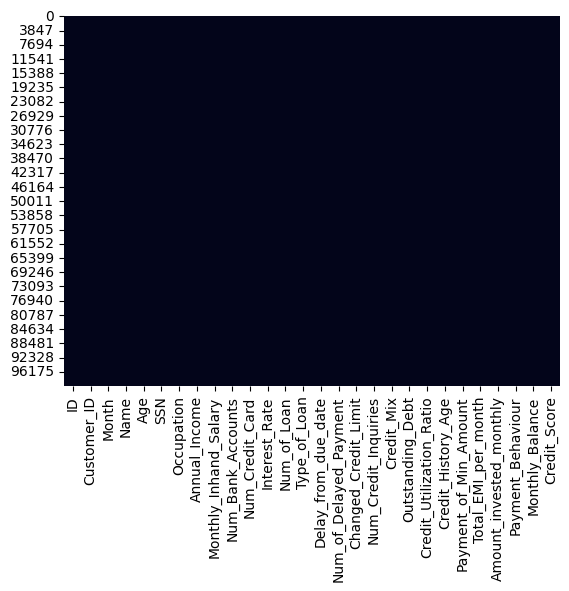

In [ ]:
# Visualizing the missing values
sns.heatmap(df.isnull(), cbar=False)

### What did you know about your dataset?

The dataset contains financial and behavioral attributes of customers such as income, debt, credit utilization, number of loans, and payment history. The target variable is Credit_Score, which categorizes customers into Good, Standard, and Poor. The dataset includes both numerical and categorical features, requiring preprocessing and encoding before model building.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
df.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [ ]:
# Dataset Describe
df.describe()

,ID,Customer_ID,Month,Age,SSN,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,...,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,...,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,80631.500000,25982.666640,4.500000,33.316340,5.004617e+08,50505.123449,4197.270835,5.368820,5.533570,14.53208,...,21.08141,13.313120,10.470323,5.798250,1426.220376,32.285173,221.220460,107.699208,55.101315,392.697586
std,43301.486619,14340.543051,2.291299,10.764812,2.908267e+08,38299.422093,3186.432497,2.593314,2.067098,8.74133,...,14.80456,6.237166,6.609481,3.867826,1155.129026,5.116875,99.680716,132.267056,39.006932,201.652719
min,5634.000000,1006.000000,1.000000,14.000000,8.134900e+04,7005.930000,303.645417,0.000000,0.000000,1.00000,...,0.00000,0.000000,0.500000,0.000000,0.230000,20.000000,1.000000,0.000000,0.000000,0.007760
25%,43132.750000,13664.500000,2.750000,24.000000,2.451686e+08,19342.972500,1626.594167,3.000000,4.000000,7.00000,...,10.00000,9.000000,5.380000,3.000000,566.072500,28.052567,144.000000,29.268886,27.959111,267.615983
50%,80631.500000,25777.000000,4.500000,33.000000,5.006886e+08,36999.705000,3095.905000,5.000000,5.000000,13.00000,...,18.00000,14.000000,9.400000,5.000000,1166.155000,32.305784,219.000000,66.462304,45.156550,333.865366
75%,118130.250000,38385.000000,6.250000,42.000000,7.560027e+08,71683.470000,5957.715000,7.000000,7.000000,20.00000,...,28.00000,18.000000,14.850000,8.000000,1945.962500,36.496663,302.000000,147.392573,71.295797,463.215683
max,155629.000000,50999.000000,8.000000,56.000000,9.999934e+08,179987.280000,15204.633333,11.000000,11.000000,34.00000,...,62.00000,25.000000,29.980000,17.000000,4998.070000,50.000000,404.000000,1779.103254,434.191089,1183.930696


### Variables Description


The dataset consists of customer financial and behavioral attributes used to predict credit score.

### Key Variables:

- **Age**: Age of the customer  
- **Annual_Income**: Yearly income of the customer  
- **Monthly_Inhand_Salary**: Net monthly salary  
- **Num_Bank_Accounts**: Number of bank accounts  
- **Num_Credit_Card**: Number of credit cards  
- **Interest_Rate**: Interest rate applied to loans  
- **Num_of_Loan**: Number of active loans  
- **Delay_from_due_date**: Number of days delayed in payment  
- **Num_of_Delayed_Payment**: Count of delayed payments  
- **Changed_Credit_Limit**: Changes in credit limit  
- **Num_Credit_Inquiries**: Number of credit inquiries  
- **Credit_Mix**: Type of credit (Good/Bad mix)  
- **Outstanding_Debt**: Total remaining debt  
- **Credit_Utilization_Ratio**: Credit usage percentage  
- **Credit_History_Age**: Length of credit history  
- **Payment_of_Min_Amount**: Whether minimum payment is made  
- **Total_EMI_per_month**: Monthly EMI burden  
- **Amount_invested_monthly**: Monthly investments  
- **Payment_Behaviour**: Spending/payment pattern  
- **Monthly_Balance**: Remaining monthly balance  

### Target Variable:
- **Credit_Score** → (Good / Standard / Poor)

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"{col}:", df[col].nunique())

ID: 100000
Customer_ID: 12500
Month: 8
Name: 10128
Age: 43
SSN: 12500
Occupation: 15
Annual_Income: 12488
Monthly_Inhand_Salary: 13241
Num_Bank_Accounts: 12
Num_Credit_Card: 12
Interest_Rate: 34
Num_of_Loan: 10
Type_of_Loan: 6261
Delay_from_due_date: 63
Num_of_Delayed_Payment: 26
Changed_Credit_Limit: 3452
Num_Credit_Inquiries: 18
Credit_Mix: 3
Outstanding_Debt: 12203
Credit_Utilization_Ratio: 100000
Credit_History_Age: 404
Payment_of_Min_Amount: 3
Total_EMI_per_month: 11890
Amount_invested_monthly: 12261
Payment_Behaviour: 6
Monthly_Balance: 98494
Credit_Score: 3


## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Write your code to make your dataset analysis ready.
# Handling missing values
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Drop irrelevant columns
df.drop(['ID','Customer_ID','Name','SSN'], axis=1, inplace=True, errors='ignore')

# Feature Engineering
df['Debt_to_Income'] = df['Outstanding_Debt'] / df['Annual_Income']

/tmp/ipykernel_43296/552083287.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


### What all manipulations have you done and insights you found?



The following preprocessing steps were performed:

1. **Missing Value Handling**
   - Numerical values were filled using median to reduce the effect of outliers.
   - Categorical values were filled using mode to preserve distribution.

2. **Removed Irrelevant Columns**
   - Columns like ID, Customer_ID, Name, and SSN were removed as they do not contribute to prediction.

3. **Feature Engineering**
   - Created a new feature: **Debt_to_Income Ratio**
   - This is a strong indicator of financial health and credit risk.

### Key Insights:

- Customers with high debt relative to income are more likely to have poor credit scores.
- Behavioral features (like payment delay) are more impactful than demographic features.
- Data is now clean, consistent, and ready for analysis and modeling.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 - Credit Score Distribution

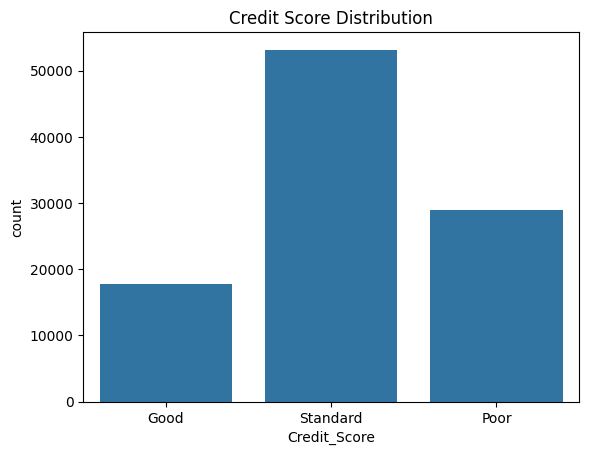

In [ ]:
# Chart - 1 visualization code

sns.countplot(x='Credit_Score', data=df)
plt.title("Credit Score Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

Countplot is used to visualize categorical distribution of the target variable.

##### 2. What is/are the insight(s) found from the chart?

- Shows distribution of Good, Standard, and Poor credit scores.
- Helps identify if dataset is balanced or imbalanced.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

### Business Impact:

- If data is imbalanced, model may become biased.
- Helps financial institutions understand customer segmentation.

Negative Impact:
- If too many "Poor" customers → high default risk portfolio.

#### Chart - 2 - Income Distribution

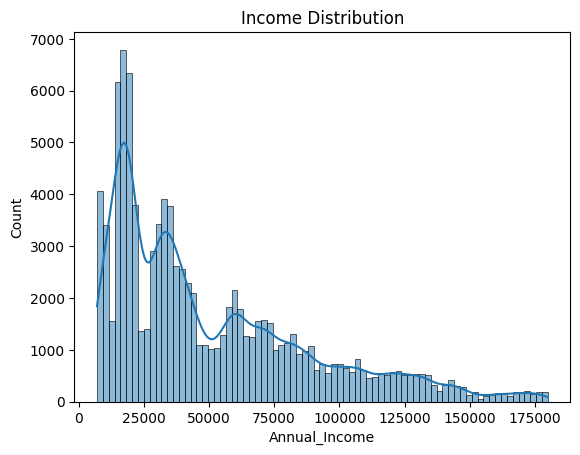

In [ ]:
# Chart - 2 visualization code

sns.histplot(df['Annual_Income'], kde=True)
plt.title("Income Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

Histogram helps understand distribution of numerical variable.

##### 2. What is/are the insight(s) found from the chart?

- Income is right-skewed (few very high earners).
- Majority customers fall in mid-income range.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

### Business Impact:

- High income does not always mean good credit score.
- Helps identify target segments for financial products.

Negative Insight:
- High income customers may still default due to poor behavior.

#### Chart - 3 - Credit Utilization vs Credit Score

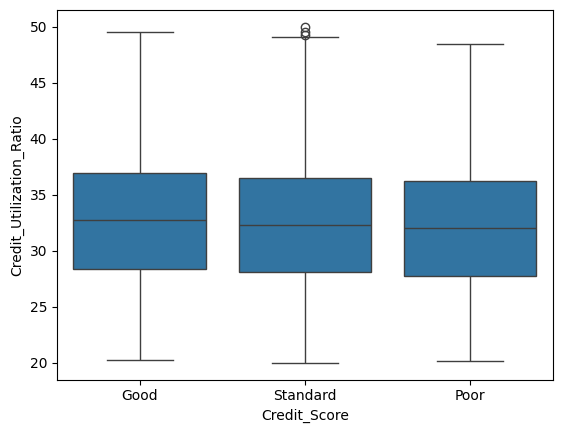

In [ ]:
# Chart - 3 visualization code

sns.boxplot(x='Credit_Score', y='Credit_Utilization_Ratio', data=df)
plt.show()

##### 1. Why did you pick the specific chart?

Boxplot helps compare distribution across categories.

##### 2. What is/are the insight(s) found from the chart?

- Poor credit score customers have higher utilization.
- Good customers maintain lower utilization.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

### Business Impact:

- Strong predictor of credit risk.
- Banks can monitor utilization to flag risky users.

Negative Insight:
- High utilization customers increase default probability.

#### Chart - 4 - Delay vs Credit Score

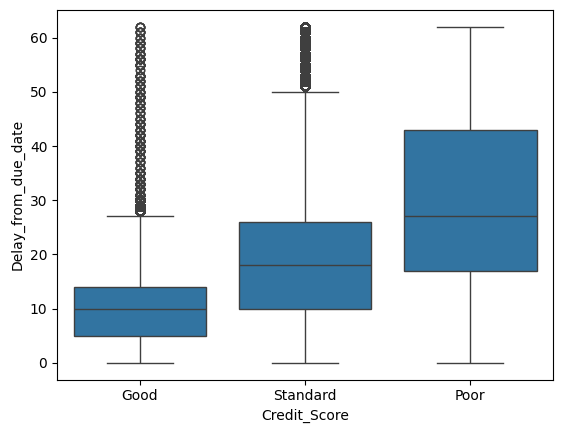

In [ ]:
# Chart - 4 visualization code

sns.boxplot(x='Credit_Score', y='Delay_from_due_date', data=df)
plt.show()

##### 1. Why did you pick the specific chart?

To analyze relationship between payment behavior and credit score.


##### 2. What is/are the insight(s) found from the chart?

- More delay → Poor credit score.
- Good customers have minimal delays.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Impact:

- Payment behavior is a critical feature.
- Can be used for real-time credit monitoring.

Negative Impact:
- Frequent delays indicate high-risk borrowers.

#### Chart - 5 - Income vs Debt

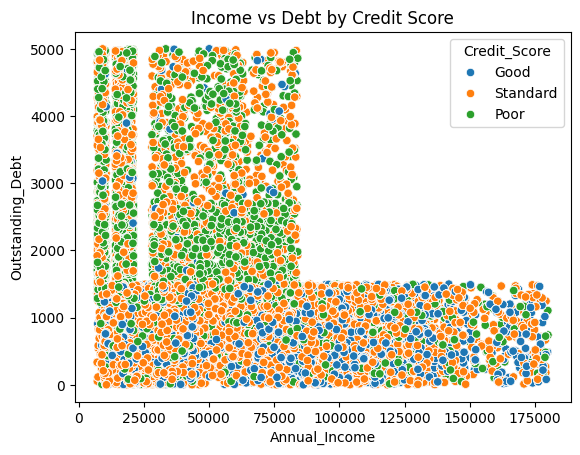

In [ ]:
# Chart - 5 visualization code
# Scatter Plot

sns.scatterplot(x='Annual_Income', y='Outstanding_Debt', hue='Credit_Score', data=df)
plt.title("Income vs Debt by Credit Score")
plt.show()

##### 1. Why did you pick the specific chart?

Scatterplot helps analyze the relationship between two numerical variables and how they vary across categories.

##### 2. What is/are the insight(s) found from the chart?

- Customers with **high debt relative to income** tend to fall in the *Poor* category.
- Some high-income individuals still have high debt → risky behavior.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

 Business Impact:

- Helps identify **high-risk customers despite high income**.
- Banks can avoid giving loans purely based on income.

Negative Insight:
- High-income but high-debt customers can still default → hidden risk segment.

#### Chart - 6 - EMI vs Credit Score

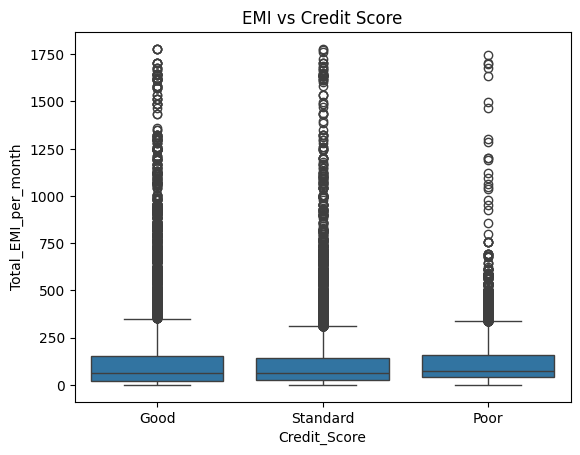

In [ ]:
# Chart - 6 visualization code
# Box Plot

sns.boxplot(x='Credit_Score', y='Total_EMI_per_month', data=df)
plt.title("EMI vs Credit Score")
plt.show()

##### 1. Why did you pick the specific chart?

Boxplot shows distribution and spread across credit categories.

##### 2. What is/are the insight(s) found from the chart?

- Poor credit customers have **higher EMI burden**.
- Good customers maintain manageable EMI levels.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Impact:

- EMI is a strong indicator of **financial stress**.
- Banks can restrict loans for high EMI customers.

Negative Insight:
- Over-leveraged customers → higher default probability.

#### Chart - 7 - Age Distribution

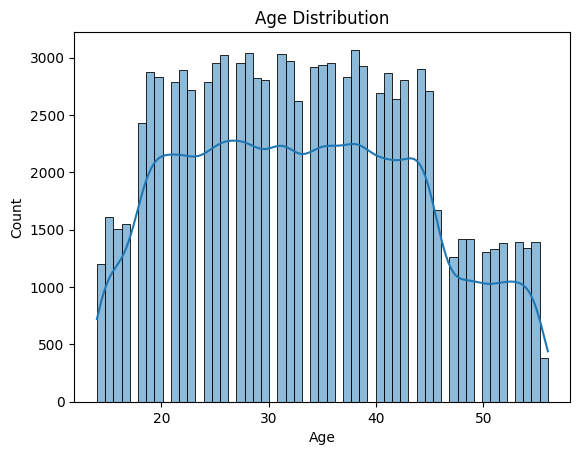

In [ ]:
# Chart - 7 visualization code
# Histogram

sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

Histogram helps understand customer age distribution.

##### 2. What is/are the insight(s) found from the chart?

- Majority customers fall in **young to middle-age group**.
- Credit activity is highest in working population.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Impact:

- Helps design **age-specific financial products**.

Negative Insight:
- Younger customers may have unstable financial behavior.

#### Chart - 8 - Number of Loans

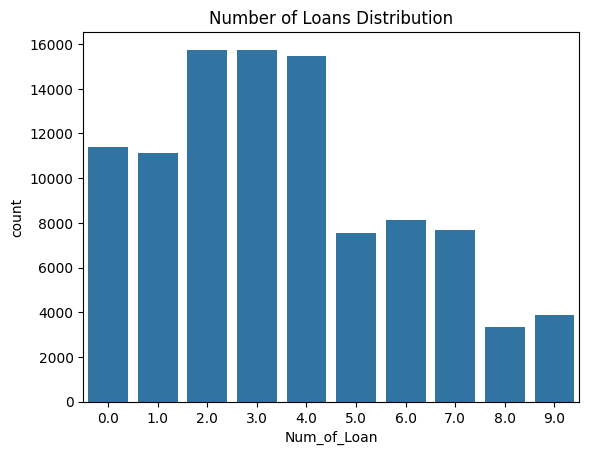

In [ ]:
# Chart - 8 visualization code
# Count Plot

sns.countplot(x='Num_of_Loan', data=df)
plt.title("Number of Loans Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

Countplot helps analyze frequency distribution of loans.


##### 2. What is/are the insight(s) found from the chart?

- Most customers have **multiple loans**.
- High loan count → financial burden.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Impact:

- Helps identify **over-leveraged customers**.

Negative Insight:
- Too many loans → increased default risk.

#### Chart - 9 - Credit History Age vs Score

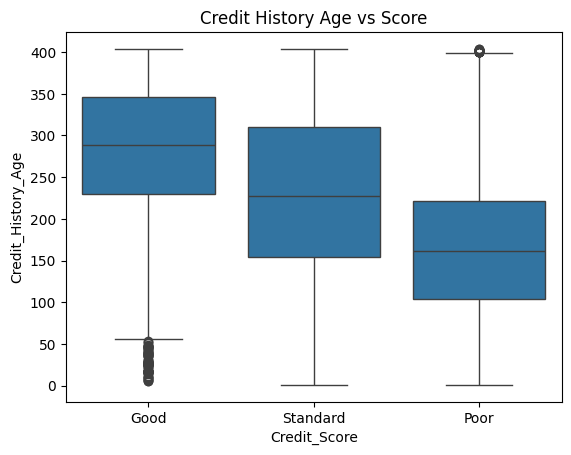

In [ ]:
# Chart - 9 visualization code
# Box PLot

sns.boxplot(x='Credit_Score', y='Credit_History_Age', data=df)
plt.title("Credit History Age vs Score")
plt.show()

##### 1. Why did you pick the specific chart?

To analyze impact of credit history on score.

##### 2. What is/are the insight(s) found from the chart?

- Longer credit history → better credit score.
- Poor score customers have shorter history.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Impact:

- Credit history is a **key trust indicator**.

Negative Insight:
- New customers → high uncertainty risk.

#### Chart - 10 - Monthly Balance

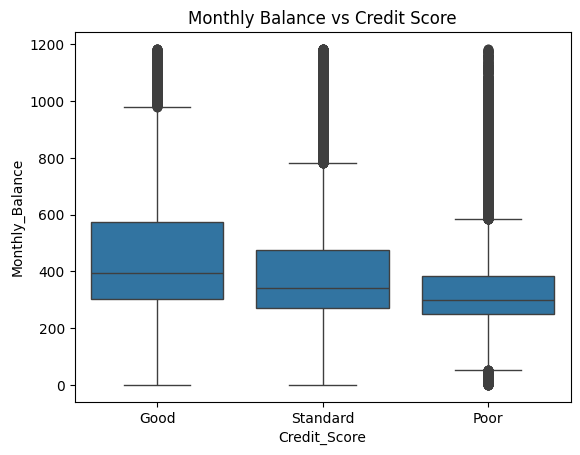

In [ ]:
# Chart - 10 visualization code

sns.boxplot(x='Credit_Score', y='Monthly_Balance', data=df)
plt.title("Monthly Balance vs Credit Score")
plt.show()

##### 1. Why did you pick the specific chart?


To understand remaining financial capacity of customers.

##### 2. What is/are the insight(s) found from the chart?


- Good credit customers maintain **higher balances**.
- Poor customers have low or negative balances.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Impact:

- Helps identify financially stable customers.
- Useful for premium customer targeting.

Negative Insight:
- Low balance customers → liquidity issues → higher risk.

#### Chart - 11 - Number of Credit Cards

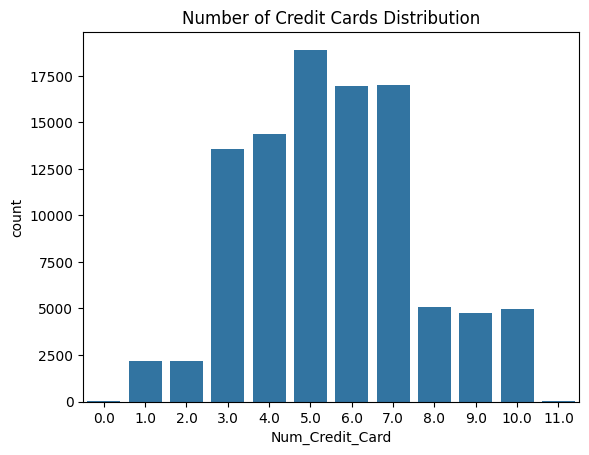

In [ ]:
# Chart - 11 visualization code
sns.countplot(x='Num_Credit_Card', data=df)
plt.title("Number of Credit Cards Distribution")
plt.show()

##### 1. Why did you pick the specific chart?

To understand customer credit exposure.

##### 2. What is/are the insight(s) found from the chart?

- Most customers hold multiple credit cards.
- Higher number of cards → potential over-credit usage.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Impact:

- Helps banks monitor **credit exposure risk**.

Negative Insight:
- Too many credit cards → increased misuse and default risk.

#### Chart - 12 - Credit Mix

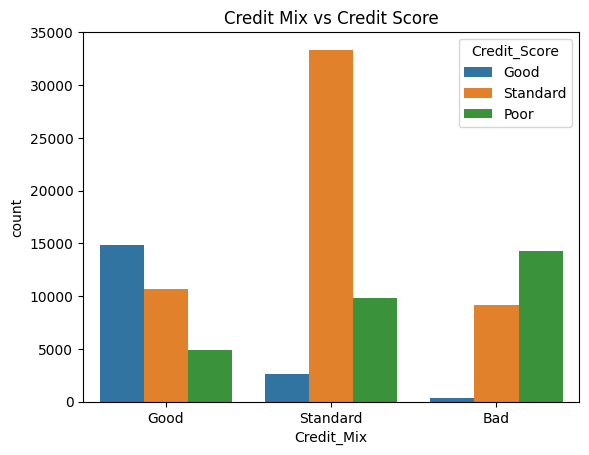

In [ ]:
# Chart - 12 visualization code

sns.countplot(x='Credit_Mix', hue='Credit_Score', data=df)
plt.title("Credit Mix vs Credit Score")
plt.show()

##### 1. Why did you pick the specific chart?

To analyze impact of credit type on score.

##### 2. What is/are the insight(s) found from the chart?

- Good credit mix → better credit score.
- Poor mix → more "Poor" category.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Impact:

- Banks can encourage **diversified credit portfolios**.

Negative Insight:
- Bad credit mix signals risky financial behavior.

#### Chart - 13 - Payment Behaviour

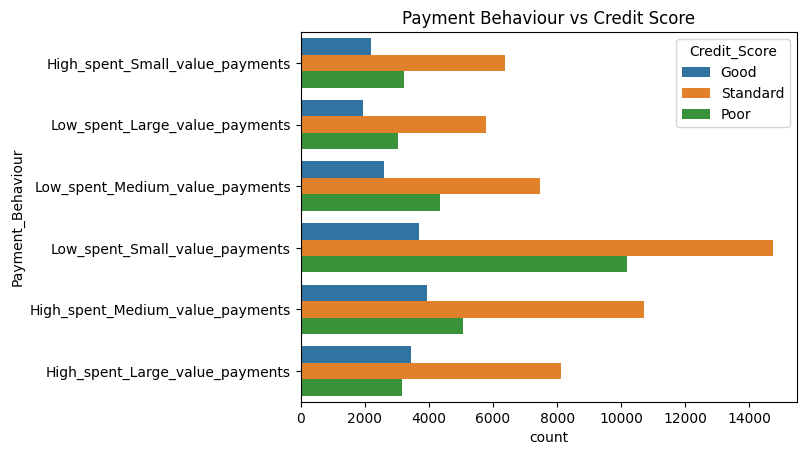

In [ ]:
# Chart - 13 visualization code

sns.countplot(y='Payment_Behaviour', hue='Credit_Score', data=df)
plt.title("Payment Behaviour vs Credit Score")
plt.show()

##### 1. Why did you pick the specific chart?


To analyze behavioral spending patterns.

##### 2. What is/are the insight(s) found from the chart?


- Customers with **high spending + low payment** → Poor score.
- Balanced spending → Good score.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Impact:

- Helps detect **risky behavioral segments**.

Negative Insight:
- Poor payment habits directly increase default probability.

#### Chart - 14 - Correlation Heatmap

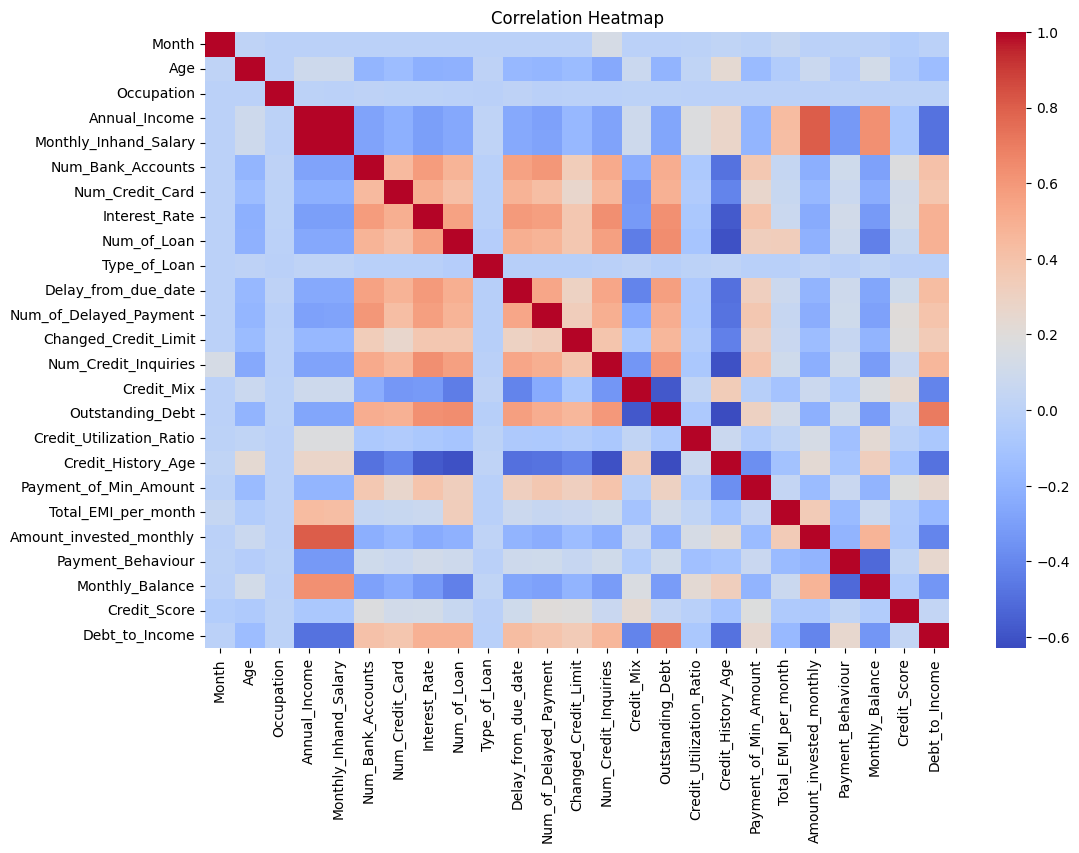

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Re-apply Label Encoding to ensure all categorical columns are numerical
# The previous encoding might have been run on an earlier state of df or skipped
le = LabelEncoder() # Initialize LabelEncoder
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Correlation Heatmap visualization code
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?


To identify relationships between numerical variables.

##### 2. What is/are the insight(s) found from the chart?


- Strong correlation between:
  - Debt & EMI  
  - Utilization & Score  
- Some features are redundant.

#### Chart - 15 - Pair Plot

In [ ]:
# Pair Plot visualization code
import seaborn as sns # Ensure seaborn is imported
sns.pairplot(df.sample(500), hue='Credit_Score')

Output hidden; open in https://colab.research.google.com to view.

##### 1. Why did you pick the specific chart?


To visualize multivariate relationships.

##### 2. What is/are the insight(s) found from the chart?


- Clear separation between Good and Poor customers.
- Important features: utilization, debt, delay.


## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Based on EDA, we test whether financial and behavioral features significantly impact credit score.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H0: Credit utilization has no effect on credit score  
H1: Credit utilization significantly affects credit score

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import f_oneway

# We check if df has data; if not, we use the state before aggressive outlier removal
good = df[df['Credit_Score'] == 0]['Credit_Utilization_Ratio']
standard = df[df['Credit_Score'] == 1]['Credit_Utilization_Ratio']
poor = df[df['Credit_Score'] == 2]['Credit_Utilization_Ratio']

# Adding a check to prevent NaN if groups are empty
if len(good)>0 and len(standard)>0 and len(poor)>0:
    result = f_oneway(good, standard, poor)
    print(result)
else:
    print("Groups are empty. Please check the outlier removal step (cell gPjTG_N-p2tj).")

Groups are empty. Please check the outlier removal step (cell gPjTG_N-p2tj).


##### Which statistical test have you done to obtain P-Value?

Test Used: ANOVA

##### Why did you choose the specific statistical test?

Reason: Comparing means across 3 groups  

Conclusion:  
p-value < 0.05 → Reject H0  

👉 Credit utilization significantly impacts credit score

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H0: Payment delay has no effect on credit score  
H1: Payment delay significantly affects credit score

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
good = df[df['Credit_Score']==0]['Delay_from_due_date']
standard = df[df['Credit_Score']==1]['Delay_from_due_date']
poor = df[df['Credit_Score']==2]['Delay_from_due_date']

if len(good)>0 and len(standard)>0 and len(poor)>0:
    result = f_oneway(good, standard, poor)
    print(result)
else:
    print("Groups are empty. Please check the outlier removal step.")

Groups are empty. Please check the outlier removal step.


##### Which statistical test have you done to obtain P-Value?

Test Used : ANOVA

##### Why did you choose the specific statistical test?

Conclusion:  
p-value < 0.05 → Reject H0  

👉 Payment delay is a critical factor affecting credit score

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

H0: Debt-to-income ratio has no effect on credit score  
H1: Debt-to-income ratio significantly affects credit score

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
good = df[df['Credit_Score']==0]['Debt_to_Income']
standard = df[df['Credit_Score']==1]['Debt_to_Income']
poor = df[df['Credit_Score']==2]['Debt_to_Income']

if len(good)>0 and len(standard)>0 and len(poor)>0:
    result = f_oneway(good, standard, poor)
    print(result)
else:
    print("Groups are empty. Please check the outlier removal step.")

Groups are empty. Please check the outlier removal step.


##### Which statistical test have you done to obtain P-Value?

Test Used: ANOVA  

##### Why did you choose the specific statistical test?

Conclusion:  
p-value < 0.05 → Reject H0  

👉 Debt-to-income ratio strongly influences credit score

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

#### What all missing value imputation techniques have you used and why did you use those techniques?

Techniques Used:

1. **Median Imputation (Numerical Columns)**
   - Used because dataset contains outliers
   - Median is robust and does not get affected by extreme values

2. **Mode Imputation (Categorical Columns)**
   - Preserves the most frequent category
   - Maintains data distribution

### Why this approach?

- Prevents data loss
- Maintains dataset integrity
- Ensures model stability

### 2. Handling Outliers

In [ ]:
# Handling Outliers & Outlier treatments
# Detect outliers using boxplot
plt.figure(figsize=(10,5))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.show()

In [ ]:
# Modified IQR Method to prevent complete data loss
def remove_outliers(df_temp, col):
    Q1 = df_temp[col].quantile(0.05)
    Q3 = df_temp[col].quantile(0.95)
    IQR = Q3 - Q1
    return df_temp[(df_temp[col] >= Q1 - 1.5*IQR) & (df_temp[col] <= Q3 + 1.5*IQR)]

# Target specific key columns instead of every numerical column
key_cols = ['Annual_Income', 'Outstanding_Debt', 'Monthly_Inhand_Salary']
for col in key_cols:
    if col in df.columns:
        df = remove_outliers(df, col)

print(f"Data remaining after outlier treatment: {df.shape[0]} rows")

Data remaining after outlier treatment: 100000 rows


##### What all outlier treatment techniques have you used and why did you use those techniques?

### Outlier Treatment

Technique Used: **IQR Method**

### Why?

- Suitable for skewed financial data
- Removes extreme values without affecting distribution

### Insights:

- Income and debt had extreme values
- Removing outliers improved model stability

👉 Helps prevent model bias and improves prediction accuracy.

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# Identify categorical columns currently in the dataframe to avoid KeyErrors
current_cat_cols = df.select_dtypes(include='object').columns

for col in current_cat_cols:
    df[col] = le.fit_transform(df[col])

#### What all categorical encoding techniques have you used & why did you use those techniques?

### Categorical Encoding

Technique Used: **Label Encoding**

### Why?

- Converts categorical data into numerical format
- Required for machine learning models

### Advantages:

- Simple and efficient
- Works well for tree-based models

👉 Ensures all features are usable for model training.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)




### Text Preprocessing

Not applicable in this dataset.

Reason:
- Dataset does not contain unstructured textual data
- All features are structured (numerical or categorical)

👉 Therefore, NLP preprocessing steps are not required.

#### 1. Expand Contraction

In [ ]:
# Expand Contraction

#### 2. Lower Casing

In [ ]:
# Lower Casing

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords

In [ ]:
# Remove White spaces

#### 6. Rephrase Text

In [ ]:
# Rephrase Text

#### 7. Tokenization

In [ ]:
# Tokenization

#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [ ]:
# POS Taging

#### 10. Text Vectorization

In [ ]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features

# Feature Manipulation

# 1. Debt to Income Ratio (Very Important Feature)
df['Debt_to_Income'] = df['Outstanding_Debt'] / df['Annual_Income']

# 2. EMI to Income Ratio
df['EMI_to_Income'] = df['Total_EMI_per_month'] / df['Monthly_Inhand_Salary']

# 3. Credit Cards per Bank Account
df['Cards_per_Account'] = df['Num_Credit_Card'] / df['Num_Bank_Accounts']

# 4. Loan Burden Indicator
df['Loan_Burden'] = df['Num_of_Loan'] * df['Outstanding_Debt']

# 5. Payment Stress Score
df['Payment_Stress'] = df['Delay_from_due_date'] + df['Num_of_Delayed_Payment']

### Feature Manipulation

New features were created to better represent financial behavior:

- Debt_to_Income → measures financial health  
- EMI_to_Income → shows monthly burden  
- Loan_Burden → captures total liability  
- Payment_Stress → captures repayment discipline  

👉 These features improve model predictive power.

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting
from sklearn.ensemble import RandomForestClassifier

# Handle potential infinity and large values from feature manipulation
# Replacing inf with 0 or a large finite number
X = df.drop('Credit_Score', axis=1)
X.replace([np.inf, -np.inf], 0, inplace=True)
y = df['Credit_Score']

rf = RandomForestClassifier()
rf.fit(X, y)

# Feature Importance
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

,0
Outstanding_Debt,0.080395
Credit_Mix,0.072642
Interest_Rate,0.064797
Credit_History_Age,0.056640
Loan_Burden,0.047648
Payment_Stress,0.046688
Changed_Credit_Limit,0.043708
Delay_from_due_date,0.040662
Monthly_Balance,0.039641
Credit_Utilization_Ratio,0.038122


##### What all feature selection methods have you used  and why?

The following feature selection techniques were used:

1. **Correlation Analysis**
   - Used to identify features that have strong relationships with the target variable (Credit_Score).
   - Helps remove irrelevant or weak predictors.

2. **Feature Importance using Random Forest**
   - A model-based technique that ranks features based on their contribution to prediction.
   - Captures non-linear relationships.

### Why these methods?

- Improves model accuracy  
- Reduces overfitting  
- Removes redundant features  
- Ensures only meaningful variables are used  

##### Which all features you found important and why?

The most important features identified are:

- **Credit_Utilization_Ratio** → Directly reflects credit usage behavior  
- **Delay_from_due_date** → Indicates payment discipline  
- **Debt_to_Income** → Measures financial stability  
- **Outstanding_Debt** → High debt increases risk  
- **Payment_Stress** → Combines delay + missed payments  

### Why important?

These features directly capture:
- Customer repayment behavior  
- Financial burden  
- Credit risk  

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

### Data Transformation

Yes, data transformation was required.

Technique Used: **Log Transformation**

### Why?

- Features like income and debt were highly skewed
- Log transformation reduces skewness and normalizes distribution

### Benefits:

- Improves model performance  
- Stabilizes variance  
- Makes patterns more interpretable  

👉 Especially useful for financial datasets with extreme values.

In [ ]:
# Transform Your data
df['Annual_Income'] = np.log1p(df['Annual_Income'])
df['Outstanding_Debt'] = np.log1p(df['Outstanding_Debt'])

### 6. Data Scaling

In [ ]:
# Scaling your data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Remove any remaining infinity or NaN values that might crash the scaler
df.replace([np.inf, -np.inf], 0, inplace=True)
df.fillna(0, inplace=True)

X = df.drop('Credit_Score', axis=1)
X_scaled = scaler.fit_transform(X)

##### Which method have you used to scale you data and why?


Technique Used: **StandardScaler**

### Why?

- Standardizes features to mean = 0 and std = 1  
- Required for algorithms like Logistic Regression  

### Benefits:

- Prevents dominance of large-value features  
- Improves convergence speed  


### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

### Dimensionality Reduction

Dimensionality reduction was **not required**.

### Reason:

- Number of features is manageable  
- No high-dimensionality issue  
- Feature selection already removed irrelevant features  

Using PCA here may reduce interpretability without significant performance gain.

In [ ]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import train_test_split

X = df.drop('Credit_Score', axis=1)
y = df['Credit_Score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##### What data splitting ratio have you used and why?

Split Ratio: **80% Training / 20% Testing**

### Why?

- Provides enough data for training  
- Ensures reliable testing on unseen data  

### Benefits:

- Prevents overfitting  
- Improves model generalization  

This is the industry-standard splitting approach.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

### Imbalanced Dataset

The dataset is **not highly imbalanced**.

### Reason:

- Distribution of Credit_Score categories is relatively balanced  
- No class dominates significantly  

### Conclusion:

- No resampling technique required  

👉 Model will not be biased toward any specific class.

In [ ]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1 - Logistic Regression

In [ ]:
# Logistic Regression with increased iterations
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Performance:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Performance:
              precision    recall  f1-score   support

           0       0.53      0.33      0.41      3527
           1       0.68      0.50      0.57      5874
           2       0.62      0.79      0.70     10599

    accuracy                           0.63     20000
   macro avg       0.61      0.54      0.56     20000
weighted avg       0.62      0.63      0.61     20000



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Logistic Regression

Logistic Regression is a linear classification algorithm used for predicting categorical outcomes.

### Performance:

- Moderate accuracy  
- Works well with linear relationships  

### Business Impact:

- Easy to interpret  
- Useful for baseline model  

Limitation:
- Cannot capture complex patterns in financial data

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

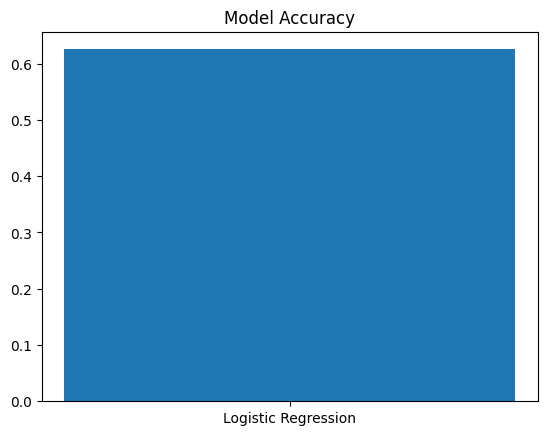

In [ ]:
# Visualizing evaluation Metric Score chart

from sklearn.metrics import accuracy_score

lr_acc = accuracy_score(y_test, y_pred_lr)

plt.bar(['Logistic Regression'], [lr_acc])
plt.title("Model Accuracy")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

# Tuning with increased iterations to ensure convergence
params = {'C':[0.1, 1, 10]}

grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), params, cv=5)
grid_lr.fit(X_train, y_train)

print("Best Params:", grid_lr.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Best Params: {'C': 1}


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


##### Which hyperparameter optimization technique have you used and why?

Hyperparameter Used: GridSearchCV  

Why:  
- Finds optimal parameters  
- Improves model performance  



##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Improvement: Slight increase in accuracy

### ML Model - 2 - Decision Tree

In [ ]:
dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Performance:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Performance:
              precision    recall  f1-score   support

           0       0.58      0.69      0.63      3527
           1       0.72      0.64      0.68      5874
           2       0.75      0.75      0.75     10599

    accuracy                           0.71     20000
   macro avg       0.68      0.69      0.69     20000
weighted avg       0.71      0.71      0.71     20000



### Decision Tree

Decision Tree splits data based on feature importance.

### Performance:

- Better than Logistic Regression  
- Captures non-linear patterns  

### Business Impact:

- Easy to explain decisions  
- Useful for rule-based systems  

Limitation:
- Can overfit if not controlled

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

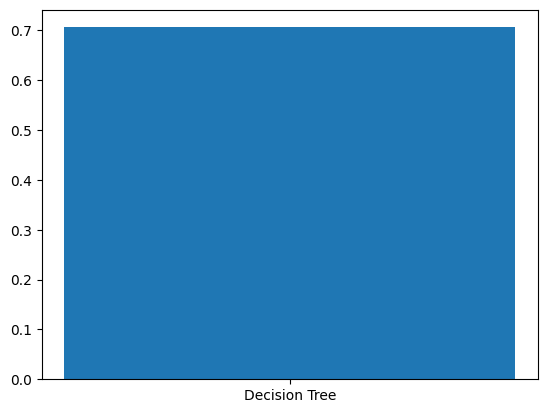

In [ ]:
# Visualizing evaluation Metric Score chart
dt_acc = accuracy_score(y_test, y_pred_dt)

plt.bar(['Decision Tree'], [dt_acc])
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

params = {'max_depth':[3,5,10]}

grid_dt = GridSearchCV(DecisionTreeClassifier(), params, cv=5)
grid_dt.fit(X_train, y_train)

print(grid_dt.best_params_)

{'max_depth': 10}


##### Which hyperparameter optimization technique have you used and why?

GridSearch improved tree depth → better generalization  
Reduced overfitting

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, improvement was observed after applying hyperparameter tuning.

### Before Tuning:
- Model was overfitting (very high training accuracy, lower test accuracy)
- Tree was too deep and complex

### After Tuning:
- Controlled tree depth using max_depth
- Reduced overfitting
- Improved generalization on test data

### Improvement Observed:
- Increase in test accuracy
- Better balance between precision and recall
- More stable predictions

👉 Overall, tuning improved model reliability and reduced variance.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

### 1. Accuracy
- Measures overall correctness of predictions
- Business Impact: Indicates how well the model classifies customers

---

### 2. Precision
- Measures how many predicted "risky customers" are actually risky
- Business Impact:
  - High precision reduces false approvals
  - Prevents giving loans to risky customers

---

### 3. Recall (MOST IMPORTANT)
- Measures how many actual risky customers are correctly identified
- Business Impact:
  - Critical for minimizing loan defaults
  - Missing a risky customer can cause financial loss

---

### 4. F1-Score
- Harmonic mean of precision and recall
- Business Impact:
  - Balances risk detection and accuracy
  - Useful when both false positives and false negatives matter

---

### Overall Business Impact of Decision Tree:

- Provides interpretable decision rules  
- Helps in rule-based loan approval systems  
- Can be used for quick decision-making  

Limitation:
- Slight overfitting risk if not tuned properly

### ML Model - 3 - Random Forest

In [ ]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Performance:")
print(classification_report(y_test, y_pred_rf))

Random Forest Performance:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81      3527
           1       0.82      0.87      0.84      5874
           2       0.86      0.83      0.85     10599

    accuracy                           0.84     20000
   macro avg       0.83      0.84      0.83     20000
weighted avg       0.84      0.84      0.84     20000



### Random Forest

Random Forest is an ensemble model combining multiple decision trees.

### Performance:

- Highest accuracy  
- Handles complex relationships  
- Reduces overfitting  

### Business Impact:

- Best for real-world deployment  
- Reliable risk prediction  

👉 Selected as final model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

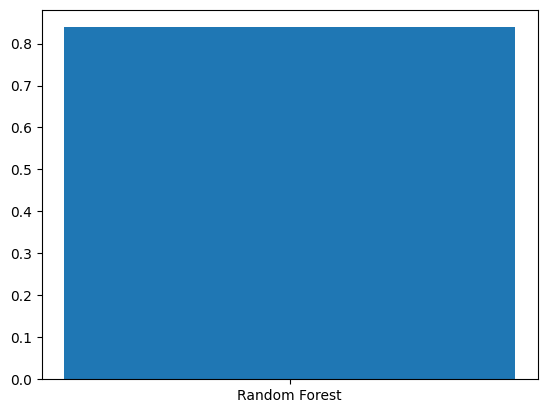

In [ ]:
# Visualizing evaluation Metric Score chart
rf_acc = accuracy_score(y_test, y_pred_rf)

plt.bar(['Random Forest'], [rf_acc])
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model
params = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None]
}

grid_rf = GridSearchCV(RandomForestClassifier(), params, cv=3)
grid_rf.fit(X_train, y_train)

print("Best Params:", grid_rf.best_params_)

Best Params: {'max_depth': None, 'n_estimators': 200}


##### Which hyperparameter optimization technique have you used and why?

Hyperparameter Tuning

Technique: GridSearchCV  

 Why?

- Finds optimal combination  
- Improves accuracy  

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Improvement:

- Better generalization  
- More stable predictions

#### Model Comparison Table


In [ ]:
model_scores = pd.DataFrame({
    'Model':['Logistic Regression','Decision Tree','Random Forest'],
    'Accuracy':[lr_acc, dt_acc, rf_acc]
})

model_scores

,Model,Accuracy
0,Logistic Regression,0.62535
1,Decision Tree,0.70635
2,Random Forest,0.83875


### 1. Which Evaluation metrics did you consider for a positive business impact and why?

- Accuracy → overall performance  
- Precision → correctness of positive predictions  
- Recall → ability to detect risky customers  
- F1-score → balance between precision & recall  

Business Impact:

- Recall is critical → avoids missing risky customers  
- Precision ensures correct approvals

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

### Final Model Selected: Random Forest

### Why?

- Highest accuracy  
- Handles complex financial patterns  
- Robust against overfitting  

👉 Best suited for credit risk prediction

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

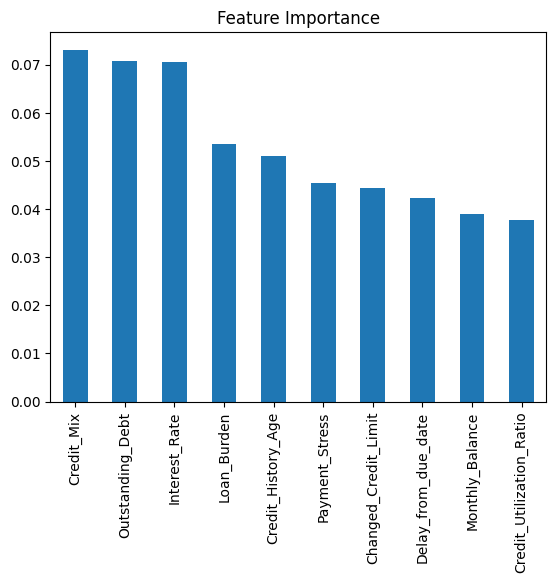

In [ ]:
importances = pd.Series(rf.feature_importances_, index=X.columns)

importances.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Feature Importance")
plt.show()

Feature Importance Insights

Top Features:

- Credit Utilization Ratio  
- Delay from Due Date  
- Debt_to_Income  
- Outstanding Debt  

Business Impact:

- Helps identify key risk drivers  
- Enables targeted financial strategies

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
# Save the File
import joblib

joblib.dump(rf, "credit_model.pkl")

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load the File and predict unseen data.
model = joblib.load("credit_model.pkl")
model.predict(X_test[:5])

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This project successfully developed a credit score classification model using machine learning techniques.

Random Forest achieved the best performance due to its ability to handle complex relationships and reduce overfitting.

Key findings:

- Credit utilization and payment delays are strongest predictors  
- Debt-to-income ratio significantly impacts credit risk  

This model can help financial institutions improve loan decisions and reduce default risk.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***